
# Condizionamento della valutazione di una funzione in un punto

## Esercizio 2 da esame - funzione logaritmica



Si consideri la funzione

$$
f(x)=\log(x), \qquad x>0.
$$

Il problema consiste nel valutare $f(x)$ in punti vicini a $1$.

Si considerino i valori

$$
x_k = 1+10^{-k}, \qquad k=1,2,\dots,15.
$$

### Richieste

1. Implementare la funzione $f(x)=\log(x)$ e calcolare $f(x_k)$ per $k=1,\dots,15$. **[1 punti]**

2. Ricavare il numero di condizionamento relativo del problema di valutare $f$ in un punto $x$  **[4 punti]**

3. Calcolare $K_f(x_k)$ per i valori assegnati di $k$. **[1 punti]**

4. Perturbare i dati ponendo

$$
\widetilde{x}_k=x_k(1+\delta),
$$

con $\delta=10^{-12}$ e confrontare l'errore relativo sul dato con l'errore relativo sul risultato. **[2 punti]**

5. Rappresentare in un grafico, in scala logaritmica, il numero di condizionamento e il rapporto tra errore relativo sul risultato ed errore relativo sul dato. **[1 punti]**

6. Commentare i risultati ottenuti e spiegare perché il problema diventa mal condizionato per $x$ vicino a $1$. **[1 punto]**

Totale: **10 punti**.


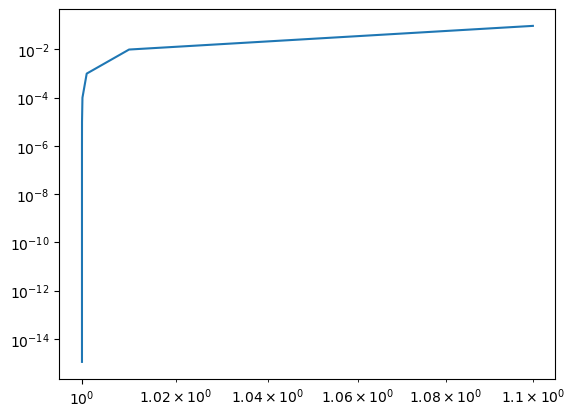

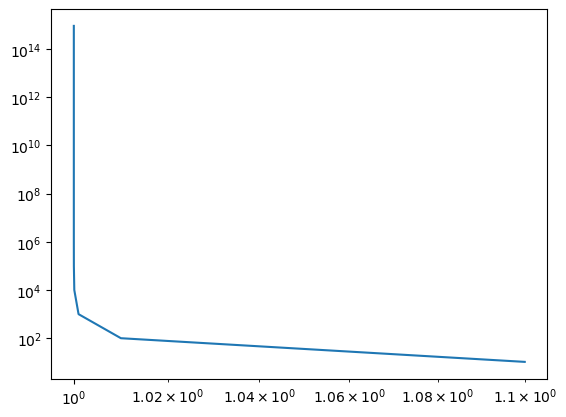

rapporto :  [1.04921778e+01 1.00499183e+02 1.00049983e+03 1.00005001e+04
 1.00000500e+05 1.00000050e+06 1.00000005e+07 1.00000001e+08
 9.99999918e+08 9.99999917e+09 9.99999917e+10 9.99911107e+11
 1.00079992e+13 1.00079992e+14 9.00719925e+14]


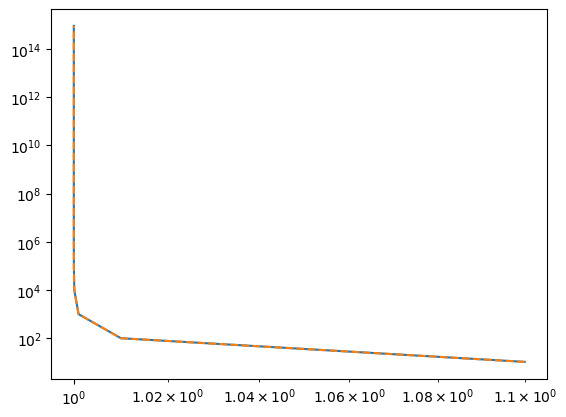

In [17]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt 
import scipy.linalg as spl

x = sym.symbols("x")
f = sym.log(x)
fl = sym.lambdify(x, f, np)
k = np.arange(1, 16)
xk = 1 + 10.0 ** (-k)
plt.loglog(xk, fl(xk))

df = sym.diff(f, x, 1)
dfl = sym.lambdify(x, df, np)
kf = sym.Abs((df * x)/ f)
kfl = sym.lambdify(x, kf, np)
plt.show()
plt.loglog(xk, kfl(xk))
plt.show()
gamma = 10.0 ** (-12)
xkp = xk * (1 + gamma)
err_dati = np.abs(xkp - xk)/np.abs(xk)
err_ris = np.abs(fl(xkp) - fl(xk))/ np.abs(fl(xk))
rapp = err_ris / err_dati
print("rapporto : ", rapp)
plt.loglog(xk, kfl(xk))
plt.loglog(xk, rapp, '--')

Il problema è fortemente mal condizionato vicino a $1$ perché quando $x \to 1$, il valore di $\log(x)$ tende a zero al denominatore del condizionamento teorico $K_f(x) = \vert{}1/\log(x)\vert{}$, facendolo schizzare a infinito. Questo si riflette nel grafico, dove la curva del rapporto degli errori reali segue perfettamente quella teorica. Il fenomeno è dovuto alla cancellazione numerica: la macchina non ha abbastanza precisione per calcolare la piccolissima differenza nel logaritmo di numeri vicini a 1, amplificando drasticamente l'errore sul risultato.